# Lending Club credit risk scorecard

**Question:** using only what a borrower tells us on their application, how well can we predict who will default on a personal loan, and where should a lender set its approval cut-off?

**Data:** 163,987 Lending Club personal loans issued between 2007 and June 2015, keeping only loans with a known outcome: repaid or defaulted (`bad_loan`). This is a cleaned public version of Lending Club's loan book published by H2O.ai on GitHub. The notebook downloads it automatically.

**What I do here:**
1. Clean the data and split it into a training set and a test set the model never sees.
2. Group each variable into bands and measure how well it separates good and bad loans (Weight of Evidence and Information Value).
3. Fit a logistic regression and turn it into a points-based scorecard, the format most UK banks still use for retail lending.
4. Test it against two benchmarks: a gradient boosting model, and Lending Club's own interest rate.
5. Use the scores to choose an approval cut-off, looking at default rates, credit losses and income.

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SEED = 42

DATA_URL = "https://raw.githubusercontent.com/h2oai/app-consumer-loan/master/data/loan.csv"
DATA_PATH = Path("data/loan.csv")
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

Path("images").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

# Chart style: one consistent look for every figure
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "font.size": 11, "lines.linewidth": 2, "savefig.dpi": 150, "savefig.bbox": "tight",
})

df = pd.read_csv(DATA_PATH)
print(f"{len(df):,} loans, {df.shape[1]} columns")
df.head()

163,987 loans, 15 columns


,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,purpose,addr_state,dti,delinq_2yrs,revol_util,total_acc,bad_loan,longest_credit_length,verification_status
0,5000,36 months,10.650,10.000,RENT,"24,000.000",credit_card,AZ,27.650,0.000,83.700,9.000,0,26.000,verified
1,2500,60 months,15.270,0.000,RENT,"30,000.000",car,GA,1.000,0.000,9.400,4.000,1,12.000,verified
2,2400,36 months,15.960,10.000,RENT,"12,252.000",small_business,IL,8.720,0.000,98.500,10.000,0,10.000,not verified
3,10000,36 months,13.490,10.000,RENT,"49,200.000",other,CA,20.000,0.000,21.000,37.000,0,15.000,verified
4,5000,36 months,7.900,3.000,RENT,"36,000.000",wedding,AZ,11.200,0.000,28.300,12.000,0,7.000,verified


## 1. A first look

About 18% of loans defaulted. Five-year loans default nearly twice as often as three-year loans, which is a first sign that the data has real signal in it.

In [2]:
print(f"Overall default rate: {df.bad_loan.mean():.1%}")
df.groupby("term").bad_loan.agg(loans="size", default_rate="mean")

Overall default rate: 18.3%


,loans,default_rate
term,,
36 months,129950,0.154
60 months,34037,0.295


In [3]:
df.isna().sum()[lambda s: s > 0]

emp_length               5804
annual_inc                  4
delinq_2yrs                29
revol_util                193
total_acc                  29
longest_credit_length      29
dtype: int64

## 2. Cleaning and the train/test split

A few small fixes:
- `home_ownership` has a handful of rare values (OTHER, NONE, ANY). I group them as OTHER.
- `term` becomes a number of months.
- Missing values are left as they are. In a scorecard, "missing" gets its own band, because the fact that something is missing can itself be informative.

**I leave the interest rate out of the model.** Lending Club set each rate using its own credit assessment, so feeding it in would mostly copy their model rather than build mine. Instead I use the rate later as a benchmark: does my scorecard rank risk as well as Lending Club's pricing did?

The test set (30%) is kept aside and only used at the end.

In [4]:
df["home_ownership"] = df["home_ownership"].replace({"NONE": "OTHER", "ANY": "OTHER"})
df["term_months"] = df["term"].str.extract(r"(\d+)").astype(int)

NUMERIC = ["loan_amnt", "term_months", "emp_length", "annual_inc", "dti", "delinq_2yrs",
           "revol_util", "total_acc", "longest_credit_length"]
CATEGORICAL = ["home_ownership", "purpose", "addr_state", "verification_status"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "bad_loan"

train, test = train_test_split(df, test_size=0.3, stratify=df[TARGET], random_state=SEED)
print(f"Train: {len(train):,} loans ({train[TARGET].mean():.1%} default)")
print(f"Test:  {len(test):,} loans ({test[TARGET].mean():.1%} default)")

Train: 114,790 loans (18.3% default)
Test:  49,197 loans (18.3% default)


## 3. Binning, Weight of Evidence and Information Value

Each variable is split into bands. For every band I calculate:

- **Weight of Evidence (WoE)** = ln(share of all good loans in the band / share of all bad loans in the band). Positive means the band is safer than average, negative means riskier.
- **Information Value (IV)** = how much the variable separates good from bad overall. As a rough guide, below 0.02 is useless, 0.02–0.1 weak, 0.1–0.3 medium, above 0.3 strong.

For numeric variables I start with ten equal-sized bands, then merge neighbouring bands until (a) every band holds at least 5% of loans and (b) the default rate only moves in one direction. Keeping the trend one-directional makes the scorecard easier to explain: a higher debt-to-income ratio should never earn *more* points.

Categories that hold less than 1% of loans are grouped together as "Other". If a variable's "Missing" band holds under 0.5% of loans, there's too little data to measure its risk, so I give it the same WoE as the riskiest band. All bands are built on the training data only.

In [5]:
def _band_stats(bands, y):
    t = pd.DataFrame({"band": bands, "y": y}).groupby("band", observed=False)["y"].agg(["size", "sum"])
    t.columns = ["n", "bad"]
    t["rate"] = t["bad"] / t["n"].clip(lower=1)
    return t


def numeric_edges(x, y, n_start=10, min_share=0.05):
    """Equal-frequency bands, merged until each is big enough and the default rate is monotonic."""
    ok = x.notna()
    x, y = x[ok], y[ok]
    qs = np.unique(np.quantile(x, np.linspace(0, 1, n_start + 1)))
    edges = [-np.inf] + list(qs[:-1]) + [np.inf]
    edges = sorted(set(edges))
    direction = np.sign(np.corrcoef(x.rank(), y)[0, 1]) or 1
    while len(edges) > 3:
        t = _band_stats(pd.cut(x, edges), y)
        share = t["n"] / t["n"].sum()
        if (share < min_share).any():
            i = int(share.values.argmin())
            # merge the small band with whichever neighbour has the closer default rate
            if i == 0:
                j = 1
            elif i == len(t) - 1:
                j = i - 1
            else:
                left, right = abs(t.rate.iloc[i] - t.rate.iloc[i - 1]), abs(t.rate.iloc[i] - t.rate.iloc[i + 1])
                j = i - 1 if left <= right else i + 1
            del edges[max(i, j)]
            continue
        diffs = np.diff(t["rate"].values) * direction
        if (diffs < 0).any():
            bad_pairs = np.where(diffs < 0)[0]
            k = bad_pairs[np.argmin(np.abs(diffs[bad_pairs]))]
            del edges[k + 1]
            continue
        break
    return edges


def woe_table(bands, y, smoothing=0.5):
    t = _band_stats(bands, y)
    t = t[t["n"] > 0]
    t["good"] = t["n"] - t["bad"]
    g = (t["good"] + smoothing) / (t["good"].sum() + smoothing)
    b = (t["bad"] + smoothing) / (t["bad"].sum() + smoothing)
    t["woe"] = np.log(g / b)
    t["iv"] = (g - b) * t["woe"]
    return t


class WoEBinner:
    def fit(self, X, y):
        self.spec, self.tables = {}, {}
        for c in NUMERIC:
            edges = numeric_edges(X[c], y)
            bands = self._band_numeric(X[c], edges)
            self.spec[c] = edges
            t = woe_table(bands, y)
            # too few missing values to measure: treat them like the riskiest band (the cautious choice)
            if "Missing" in t.index and t.loc["Missing", "n"] < 0.005 * len(y):
                t.loc["Missing", "woe"] = t.drop(index="Missing")["woe"].min()
            self.tables[c] = t
        for c in CATEGORICAL:
            share = X[c].value_counts(normalize=True)
            keep = set(share[share >= 0.01].index)
            self.spec[c] = keep
            self.tables[c] = woe_table(self._band_cat(X[c], keep), y)
        self.iv = pd.Series({c: t["iv"].sum() for c, t in self.tables.items()}).sort_values(ascending=False)
        return self

    @staticmethod
    def _band_numeric(x, edges):
        b = pd.cut(x, edges)
        return b.cat.add_categories("Missing").fillna("Missing")

    @staticmethod
    def _band_cat(x, keep):
        return x.where(x.isin(keep), "Other").fillna("Other")

    def bands(self, X, c):
        if c in NUMERIC:
            return self._band_numeric(X[c], self.spec[c])
        return self._band_cat(X[c], self.spec[c])

    def transform(self, X, cols):
        out = {}
        for c in cols:
            woe = self.tables[c]["woe"]
            woe.index = woe.index.astype(str)
            out[c] = self.bands(X, c).astype(str).map(woe).fillna(0.0)  # unseen band -> neutral
        return pd.DataFrame(out, index=X.index)


binner = WoEBinner().fit(train[FEATURES], train[TARGET])
binner.iv.to_frame("information_value")

,information_value
term_months,0.128
revol_util,0.076
dti,0.073
annual_inc,0.063
purpose,0.033
verification_status,0.025
loan_amnt,0.025
home_ownership,0.016
total_acc,0.012
emp_length,0.010


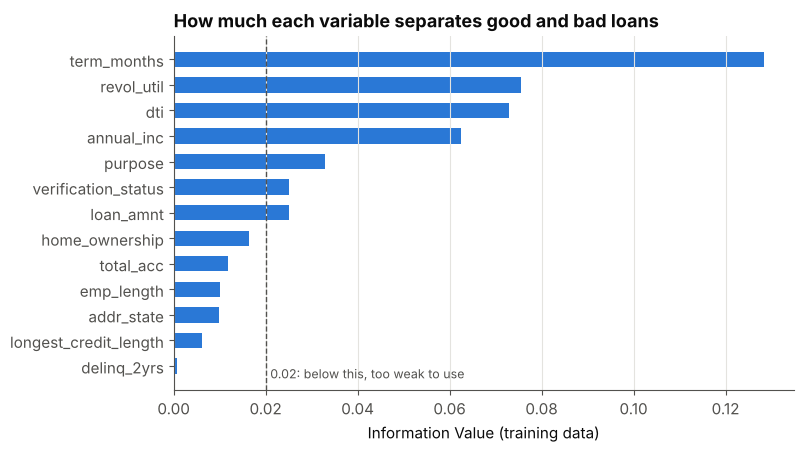

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.6))
iv = binner.iv.sort_values()
ax.barh(iv.index, iv.values, color=BLUE, height=0.6)
ax.axvline(0.02, color=INK_2, linestyle="--", linewidth=1)
ax.text(0.021, -0.6, "0.02: below this, too weak to use", color=INK_2, fontsize=9, va="bottom")
ax.set_title("How much each variable separates good and bad loans")
ax.set_xlabel("Information Value (training data)")
ax.grid(axis="y", visible=False)
plt.savefig("images/information_value.png")
plt.show()

Loan term is the strongest variable, followed by credit card utilisation (`revol_util`), debt-to-income (`dti`) and income. Delinquencies in the last two years are almost useless here, probably because Lending Club had already turned away most applicants with recent arrears.

None of the variables is very strong on its own. That's expected for application data without a credit bureau score, and it's why the scorecard combines several of them.

I keep variables with IV of at least 0.02, then check that none of the selected variables are too closely correlated with each other (above 0.7), which would make the coefficients unstable.

In [7]:
selected = binner.iv[binner.iv >= 0.02].index.tolist()
Xtr = binner.transform(train, selected)
Xte = binner.transform(test, selected)

corr = Xtr.corr().abs().where(~np.eye(len(selected), dtype=bool))
print("Selected:", selected)
print(f"Highest correlation between selected variables: {corr.max().max():.2f}")

Selected: ['term_months', 'revol_util', 'dti', 'annual_inc', 'purpose', 'verification_status', 'loan_amnt']
Highest correlation between selected variables: 0.45


Here is what the bands look like for one variable, debt-to-income (DTI). The default rate climbs steadily as DTI rises, and WoE falls with it.

In [8]:
binner.tables["dti"][["n", "rate", "woe", "iv"]].rename(columns={"rate": "default_rate"})

,n,default_rate,woe,iv
band,,,,
"(-inf, 5.94]",11495,0.129,0.416,0.015
"(5.94, 8.97]",11486,0.140,0.322,0.009
"(8.97, 11.37]",11465,0.155,0.199,0.004
"(11.37, 13.54]",11495,0.159,0.171,0.003
"(13.54, 15.62]",11483,0.171,0.079,0.001
"(15.62, 17.73]",11480,0.178,0.031,0.000
"(17.73, 20.03]",11479,0.191,-0.054,0.000
"(20.03, 22.64]",11458,0.207,-0.154,0.002
"(22.64, 26.09]",11486,0.229,-0.282,0.009


## 4. The logistic regression scorecard

In [9]:
logit = LogisticRegression(C=1e6, max_iter=1000)  # effectively unpenalised
logit.fit(Xtr, train[TARGET])
coefs = pd.Series(logit.coef_[0], index=selected)
coefs.to_frame("coefficient")

,coefficient
term_months,-0.891
revol_util,-0.900
dti,-0.494
annual_inc,-1.516
purpose,-1.037
verification_status,-0.261
loan_amnt,-0.963


Every coefficient is negative, which is what we want: WoE is higher for safer bands, so a higher WoE should lower the predicted chance of default. If any coefficient had flipped sign, that variable would be pushing the score the wrong way and I would remove it.

### Turning the model into points

I use the standard scaling: a score of **600 means odds of 50 good loans to 1 bad**, and every **20 points doubles the odds** (the "points to double the odds", or PDO). Each band of each variable then gets a fixed number of points, and an applicant's score is just the sum.

In [10]:
assert (coefs < 0).all(), "a coefficient has the wrong sign"

PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_vars = len(selected)

rows = []
for c in selected:
    t = binner.tables[c]
    for band, r in t.iterrows():
        pts = (offset - factor * logit.intercept_[0]) / n_vars - factor * coefs[c] * r["woe"]
        rows.append({"variable": c, "band": str(band), "loans": int(r["n"]),
                     "default_rate": r["rate"], "woe": r["woe"], "points": int(round(pts))})
scorecard = pd.DataFrame(rows)
scorecard.to_csv("outputs/scorecard.csv", index=False)


def score_applicants(X):
    pts = pd.Series(0.0, index=X.index)
    for c in selected:
        lookup = scorecard[scorecard.variable == c].set_index("band")["points"]
        pts += binner.bands(X, c).astype(str).map(lookup).fillna(lookup.median())
    return pts


train["score"] = score_applicants(train)
test["score"] = score_applicants(test)
print(f"Scores on the test set run from {test.score.min():.0f} to {test.score.max():.0f}")
scorecard[scorecard.variable == "term_months"]

Scores on the test set run from 468 to 595


,variable,band,loans,default_rate,woe,points
0,term_months,"(-inf, 36.0]",91059,0.154,0.208,81
1,term_months,"(36.0, inf]",23731,0.295,-0.623,60


## 5. How well does it work?

All results below are on the **test set**, which played no part in building the bands or the model.

Three measures:
- **AUC / Gini:** the chance the model ranks a random bad loan as riskier than a random good one (AUC); Gini = 2 x AUC - 1 is the version banks usually quote.
- **KS:** the biggest gap between the score distributions of good and bad loans.

Two benchmarks:
- **Gradient boosting** on the same raw variables. Usually more accurate, but much harder to explain to customers and regulators.
- **Lending Club's interest rate.** Their rate was set using their own credit model, including bureau credit scores that this dataset doesn't contain. So it's a demanding benchmark.

In [11]:
gbm_features = NUMERIC + CATEGORICAL
def gbm_frame(d):
    X = d[gbm_features].copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype("category")
    return X

gbm = HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, max_leaf_nodes=31,
                                     categorical_features="from_dtype", early_stopping=True,
                                     validation_fraction=0.15, random_state=SEED)
gbm.fit(gbm_frame(train), train[TARGET])

y = test[TARGET].values
risk = {
    "Scorecard (logistic regression)": -test["score"].values,   # lower score = riskier
    "Gradient boosting": gbm.predict_proba(gbm_frame(test))[:, 1],
    "Lending Club interest rate": test["int_rate"].values,
}


def ks_stat(y, s):
    fpr, tpr, _ = roc_curve(y, s)
    return np.max(tpr - fpr)


results = pd.DataFrame({
    name: {"AUC": roc_auc_score(y, s), "Gini": 2 * roc_auc_score(y, s) - 1, "KS": ks_stat(y, s)}
    for name, s in risk.items()
}).T
results

,AUC,Gini,KS
Scorecard (logistic regression),0.673,0.346,0.251
Gradient boosting,0.687,0.374,0.273
Lending Club interest rate,0.673,0.345,0.252


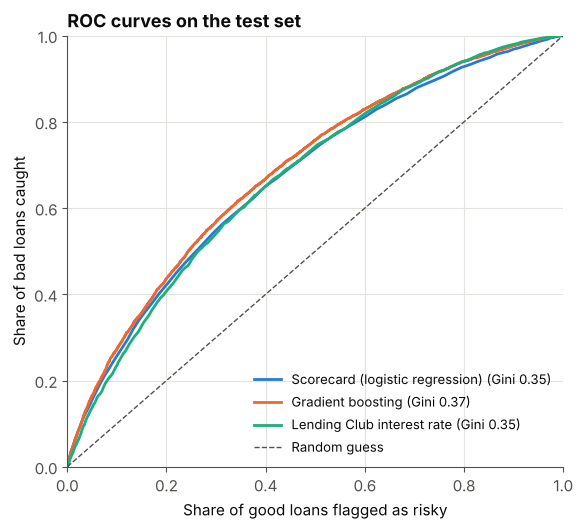

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
for (name, s), colour in zip(risk.items(), [BLUE, ORANGE, AQUA]):
    fpr, tpr, _ = roc_curve(y, s)
    ax.plot(fpr, tpr, color=colour, label=f"{name} (Gini {results.loc[name, 'Gini']:.2f})")
ax.plot([0, 1], [0, 1], color=INK_2, linestyle="--", linewidth=1, label="Random guess")
ax.set_xlabel("Share of good loans flagged as risky")
ax.set_ylabel("Share of bad loans caught")
ax.set_title("ROC curves on the test set")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False, fontsize=9.5)
plt.savefig("images/roc_curves.png")
plt.show()

### Does the score rank risk smoothly?

Splitting the test set into ten equal groups by score, the default rate should fall steadily from the lowest-scoring group to the highest.

In [13]:
test["score_band"] = pd.qcut(test["score"].rank(method="first"), 10, labels=[f"{i}" for i in range(1, 11)])
band_summary = test.groupby("score_band", observed=True).agg(
    loans=(TARGET, "size"), min_score=("score", "min"), max_score=("score", "max"),
    default_rate=(TARGET, "mean"), avg_interest_rate=("int_rate", "mean"))
band_summary

,loans,min_score,max_score,default_rate,avg_interest_rate
score_band,,,,,
1,4920,468.000,510.000,0.387,18.306
2,4920,510.000,519.000,0.286,16.268
3,4919,519.000,525.000,0.235,14.948
4,4920,525.000,529.000,0.197,14.240
5,4920,529.000,534.000,0.176,13.683
6,4919,534.000,539.000,0.154,13.036
7,4920,539.000,544.000,0.132,12.668
8,4919,544.000,549.000,0.108,12.179
9,4920,549.000,557.000,0.089,11.593


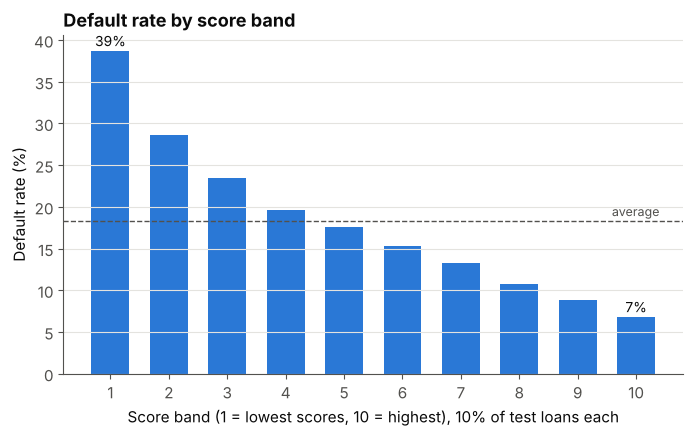

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(band_summary.index.astype(str), band_summary["default_rate"] * 100, color=BLUE, width=0.65)
for i, v in enumerate(band_summary["default_rate"] * 100):
    if i in (0, 9):
        ax.text(i, v + 0.6, f"{v:.0f}%", ha="center", color=INK, fontsize=10)
ax.axhline(test[TARGET].mean() * 100, color=INK_2, linestyle="--", linewidth=1)
ax.text(9.4, test[TARGET].mean() * 100 + 0.6, "average", color=INK_2, fontsize=9, ha="right")
ax.set_xlabel("Score band (1 = lowest scores, 10 = highest), 10% of test loans each")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate by score band")
ax.grid(axis="x", visible=False)
plt.savefig("images/default_rate_by_band.png")
plt.show()

### Is the predicted default rate right?

Ranking is one thing; the predicted probabilities also need to match reality if they're used for pricing or provisions. Comparing the average predicted probability of default (PD) with the actual default rate in each band:

In [15]:
test["pd"] = logit.predict_proba(Xte)[:, 1]
calib = test.groupby("score_band", observed=True).agg(predicted_pd=("pd", "mean"), actual_default_rate=(TARGET, "mean"))
calib["gap"] = calib["actual_default_rate"] - calib["predicted_pd"]
print(f"Largest gap between predicted and actual: {calib.gap.abs().max():.1%} points")
calib

Largest gap between predicted and actual: 0.7% points


,predicted_pd,actual_default_rate,gap
score_band,,,
1,0.382,0.387,0.005
2,0.279,0.286,0.007
3,0.233,0.235,0.002
4,0.202,0.197,-0.005
5,0.176,0.176,-0.001
6,0.155,0.154,-0.001
7,0.134,0.132,-0.002
8,0.114,0.108,-0.006
9,0.093,0.089,-0.005


## 6. Does the scorecard add anything to Lending Club's pricing?

The scorecard and Lending Club's interest rate separate good and bad loans about equally well. The interesting question is whether they're picking up the *same* information. If they were, combining them wouldn't help, and borrowers on the same interest rate would have similar default rates whatever their score.

In [16]:
Xtr_rate, Xte_rate = Xtr.copy(), Xte.copy()
Xtr_rate["int_rate"], Xte_rate["int_rate"] = train["int_rate"], test["int_rate"]
combined = LogisticRegression(C=1e6, max_iter=2000).fit(Xtr_rate, train[TARGET])
combined_auc = roc_auc_score(y, combined.predict_proba(Xte_rate)[:, 1])
print(f"Interest rate alone: Gini {results.loc['Lending Club interest rate', 'Gini']:.2f}")
print(f"Scorecard alone:     Gini {results.loc['Scorecard (logistic regression)', 'Gini']:.2f}")
print(f"Both combined:       Gini {2 * combined_auc - 1:.2f}")

test["rate_band"] = pd.qcut(test["int_rate"], 5, labels=["Lowest", "Low", "Middle", "High", "Highest"])
test["score_tier"] = pd.qcut(test["score"].rank(method="first"), 3,
                             labels=["Bottom third of scores", "Middle third", "Top third"])
rate_ranges = test.groupby("rate_band", observed=True)["int_rate"].agg(["min", "max"])
within = test.pivot_table(index="rate_band", columns="score_tier", values=TARGET, aggfunc="mean", observed=True)
within.index = [f"{b} ({lo:.1f}-{hi:.1f}%)" for b, (lo, hi) in zip(within.index, rate_ranges.values)]
within

Interest rate alone: Gini 0.35
Scorecard alone:     Gini 0.35
Both combined:       Gini 0.40


score_tier,Bottom third of scores,Middle third,Top third
Lowest (5.4-9.8%),0.142,0.098,0.044
Low (9.8-12.4%),0.202,0.135,0.088
Middle (12.5-14.5%),0.229,0.160,0.114
High (14.5-17.6%),0.300,0.185,0.149
Highest (17.6-26.1%),0.375,0.262,0.195


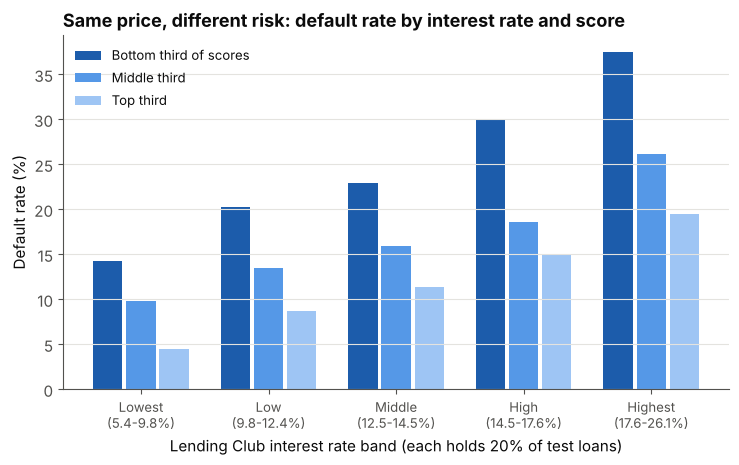

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
tiers = within.columns
shades = ["#1c5cab", "#5598e7", "#9ec5f4"]   # darker = lower score
x = np.arange(len(within))
w = 0.26
for k, (tier, shade) in enumerate(zip(tiers, shades)):
    ax.bar(x + (k - 1) * w, within[tier] * 100, width=w - 0.03, color=shade, label=tier)
ax.set_xticks(x)
ax.set_xticklabels([lbl.replace(" (", "\n(") for lbl in within.index], fontsize=9.5)
ax.set_xlabel("Lending Club interest rate band (each holds 20% of test loans)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Same price, different risk: default rate by interest rate and score")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
plt.savefig("images/same_price_different_risk.png")
plt.show()

Within every interest rate band, applicants in the bottom third of scores defaulted roughly twice as often as those in the top third. Some borrowers in the "High" band with good scores even defaulted *less* often than borrowers with poor scores paying a lower rate in the "Low" band.

So Lending Club was charging similar prices for quite different risks: information on the application form wasn't fully reflected in its rates. Putting the two together lifts the Gini from 0.35 to about 0.40, which in practice means more accurate pricing, fewer bad loans approved, or both.

## 7. Choosing an approval cut-off

A model only matters if it changes a decision. Lenders usually set a **risk appetite** first, for example "the loans we approve should default less than 15% of the time", then pick the score cut-off that meets it while turning away as few good customers as possible.

I also estimate **expected loss** for the approved book: PD x LGD x EAD, where PD is the scorecard's probability of default, EAD is the amount lent, and LGD (the share lost when a loan defaults) is **assumed to be 60%**. This version of the data doesn't record recoveries, so that figure is an assumption; for an unsecured loan that defaults around a year in, with low recoveries, it's a reasonable middle estimate.

In [18]:
LGD = 0.60
TARGET_DEFAULT_RATE = 0.15
test["pd"] = logit.predict_proba(Xte)[:, 1]
test["expected_loss"] = test["pd"] * LGD * test["loan_amnt"]


def cutoff_table(d, approval_rates):
    d = d.sort_values("score", ascending=False)
    total_bad_value = (d[TARGET] * d["loan_amnt"]).sum()
    total_good = (1 - d[TARGET]).sum()
    rows = []
    for a in approval_rates:
        approved = d.iloc[: int(round(a * len(d)))]
        rows.append({
            "approval_rate": a,
            "min_score": approved["score"].min(),
            "default_rate": approved[TARGET].mean(),
            "defaulted_lending_avoided": 1 - (approved[TARGET] * approved["loan_amnt"]).sum() / total_bad_value,
            "good_customers_turned_away": 1 - (1 - approved[TARGET]).sum() / total_good,
            "expected_loss_rate": approved["expected_loss"].sum() / approved["loan_amnt"].sum(),
        })
    return pd.DataFrame(rows)


fine = cutoff_table(test, np.round(np.arange(1.0, 0.495, -0.01), 2))
pick = fine[fine["default_rate"] < TARGET_DEFAULT_RATE].iloc[0]   # most applicants approved while meeting the target
base = fine.iloc[0]

summary_rates = sorted({1.0, 0.95, 0.9, round(pick.approval_rate, 2), 0.8, 0.7, 0.6, 0.5}, reverse=True)
cutoffs = cutoff_table(test, summary_rates)
cutoffs.to_csv("outputs/cutoff_strategy.csv", index=False)
cutoffs

,approval_rate,min_score,default_rate,defaulted_lending_avoided,good_customers_turned_away,expected_loss_rate
0,1.000,468.000,0.183,0.000,0.000,0.118
1,0.950,503.000,0.170,0.157,0.035,0.108
2,0.900,510.000,0.160,0.274,0.075,0.100
3,0.830,517.000,0.149,0.396,0.135,0.093
4,0.800,519.000,0.145,0.441,0.162,0.090
5,0.700,525.000,0.132,0.564,0.256,0.082
6,0.600,529.000,0.121,0.660,0.354,0.075
7,0.500,534.000,0.110,0.744,0.455,0.068


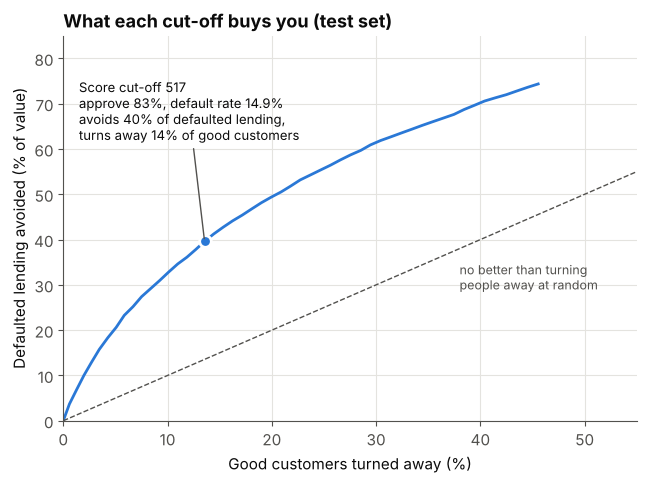

In [19]:
fig, ax = plt.subplots(figsize=(7.4, 5))
ax.plot(fine["good_customers_turned_away"] * 100, fine["defaulted_lending_avoided"] * 100, color=BLUE)
ax.plot([0, 100], [0, 100], color=INK_2, linestyle="--", linewidth=1)
ax.text(38, 29, "no better than turning\npeople away at random", color=INK_2, fontsize=9)
px, py = pick["good_customers_turned_away"] * 100, pick["defaulted_lending_avoided"] * 100
ax.scatter([px], [py], s=70, color=BLUE, edgecolor="white", linewidth=2, zorder=3)
ax.annotate(f"Score cut-off {pick['min_score']:.0f}\napprove {pick['approval_rate']:.0%}, default rate {pick['default_rate']:.1%}\n"
            f"avoids {py:.0f}% of defaulted lending,\nturns away {px:.0f}% of good customers",
            xy=(px, py), xytext=(1.5, 62), fontsize=9.5, color=INK,
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=1))
ax.set_xlim(0, 55); ax.set_ylim(0, 85)
ax.set_xlabel("Good customers turned away (%)")
ax.set_ylabel("Defaulted lending avoided (% of value)")
ax.set_title("What each cut-off buys you (test set)")
plt.savefig("images/cutoff_tradeoff.png")
plt.show()

To bring the default rate below 15%, the lender would approve applicants scoring **517 or more**, which turns away the lowest-scoring 17% of applicants. Because those applicants are much riskier than average, this avoids about 40% of the money lent to borrowers who went on to default, while losing only around 14% of good customers.

I also tried a profit view (interest earned minus credit losses). At Lending Club's interest rates it suggested approving almost everyone, but that answer swings heavily on funding and running costs that aren't in the data, so I haven't relied on it.

## 8. Summary and limitations

In [20]:
sc = results.loc["Scorecard (logistic regression)"]
gb = results.loc["Gradient boosting"]
lc = results.loc["Lending Club interest rate"]
print(f"Scorecard: Gini {sc.Gini:.2f}, KS {sc.KS:.2f}. Gradient boosting: Gini {gb.Gini:.2f}. Lending Club rate: Gini {lc.Gini:.2f}. Scorecard + rate: Gini {2 * combined_auc - 1:.2f}")
print(f"Default rate by score band: {band_summary.default_rate.iloc[0]:.1%} (lowest) to {band_summary.default_rate.iloc[-1]:.1%} (highest); "
      f"predicted PDs within {calib.gap.abs().max() * 100:.1f} points of actual")
print(f"Cut-off {pick.min_score:.0f}: approve {pick.approval_rate:.0%}, default rate {base.default_rate:.1%} -> {pick.default_rate:.1%}, "
      f"defaulted lending avoided {pick.defaulted_lending_avoided:.0%}, good customers turned away {pick.good_customers_turned_away:.0%}, "
      f"expected loss rate {base.expected_loss_rate:.1%} -> {pick.expected_loss_rate:.1%}")

Scorecard: Gini 0.35, KS 0.25. Gradient boosting: Gini 0.37. Lending Club rate: Gini 0.35. Scorecard + rate: Gini 0.40
Default rate by score band: 38.7% (lowest) to 6.8% (highest); predicted PDs within 0.7 points of actual
Cut-off 517: approve 83%, default rate 18.3% -> 14.9%, defaulted lending avoided 40%, good customers turned away 14%, expected loss rate 11.8% -> 9.3%


**What I found**
- A seven-variable scorecard built only from application data ranks risk as well as Lending Club's own interest rates did (Gini 0.35 for both), even though Lending Club also had credit bureau scores.
- Gradient boosting did a little better (Gini 0.37), but I'd still choose the scorecard for lending decisions: every point can be explained to a customer or a regulator, and the predicted default rates were almost exactly right.
- The scorecard picks up risk that Lending Club's pricing missed. Combining the two lifts the Gini to about 0.40.
- Setting the cut-off to keep defaults below 15% avoids about 40% of defaulted lending while turning away around 14% of good customers.

**Limitations**
- **No dates in this version of the data**, so I couldn't do an out-of-time test (build on older loans, test on newer ones). That's how banks normally check a model will hold up.
- **Only approved loans.** We never see how the applicants Lending Club rejected would have behaved, so the model may be less reliable at the very bottom of the score range (the "reject inference" problem).
- **LGD is assumed**, not measured, so the expected loss figures are indicative.
- **No credit bureau data**, which would normally be the strongest predictor in a real scorecard.